In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np

In [2]:
def load_loss_data(json_path):
    """Load previously saved loss data"""
    
    with open(json_path, 'r') as f:
        loss_data = json.load(f)
    print(f"Loss data loaded from {json_path}")
    return loss_data

In [8]:
def plot_loss_curves(loss_data, save_dir=None):
    """Plot training and validation loss curves as separate figures"""
    train_losses = loss_data['train_losses']
    train_physics = loss_data['train_physics_losses']
    train_boundary = loss_data['train_boundary_losses']
    epochs = list(range(len(train_losses)))
    # Plot 1: Training Loss Components
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Total Training Loss', linewidth=2, color='blue')
    plt.plot(epochs, train_physics, label='Training Physics Loss (× 10⁻²⁰)', linewidth=2, color='red')
    plt.plot(epochs, train_boundary, label='Training Boundary Loss', linewidth=2, color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Components')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
 
    plt.show()
    
 

In [4]:
def combine_training_results(file1, file2, file3, output_file):
    """Combine three training session JSON files"""
    
    # Load all files
    with open(file1, 'r') as f:
        data1 = json.load(f)
    
    with open(file2, 'r') as f:
        data2 = json.load(f)
    
    with open(file3, 'r') as f:
        data3 = json.load(f)
    
    # Combine the data
    combined = {
        'train_losses': data1['train_losses'] + data2['train_losses'] + data3['train_losses'],
        'train_physics_losses': data1['train_physics_losses'] + data2['train_physics_losses'] + data3['train_physics_losses'],
        'train_boundary_losses': data1['train_boundary_losses'] + data2['train_boundary_losses'] + data3['train_boundary_losses'],
    }
    
    # Save combined results
    with open(output_file, 'w') as f:
        json.dump(combined, f, indent=4)
    
    print(f"Combined results saved to {output_file}")
    return combined

# Usage
combined_data = combine_training_results(
    "D:/Results/loss_data2.json",
    "D:/Results/loss_data3.json", 
    "D:/Results/loss_data4.json",
    "D:/Results/conbined.json"
)

Combined results saved to D:/Results/conbined.json


Loss data loaded from D:/Results/conbined.json


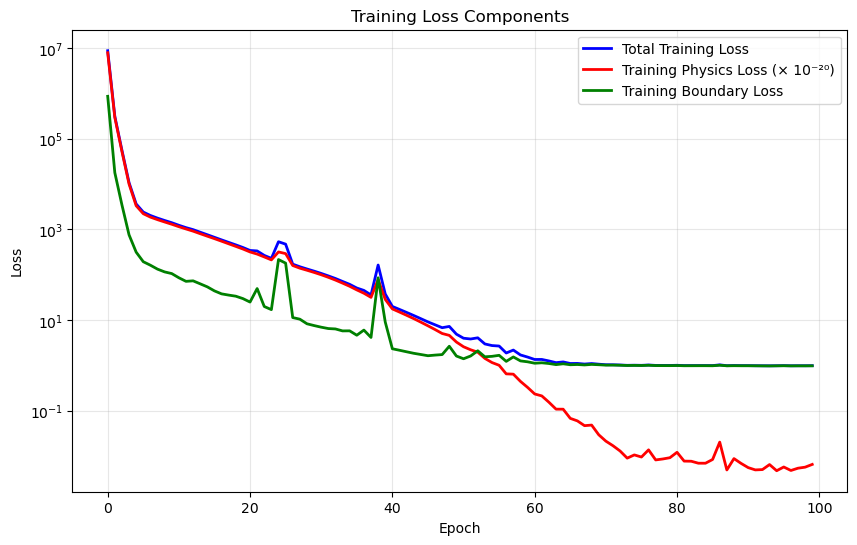

In [9]:
results_dir = "D:/Results/conbined.json"
loss_data = load_loss_data(results_dir)
plot_loss_curves(loss_data)